# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **4125 images**, divided into two categories:

- **With Helmet:** 3161 images showing workers wearing helmets.
- **Without Helmet:** 964 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [ ]:
!pip install tensorflow[and-cuda] scikit-learn opencv-python seaborn matplotlib numpy pandas -q

In [ ]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.20.0


In [ ]:
# 1. Set Python random seed
random.seed(812)

# 2. Set NumPy random seed
np.random.seed(812)

# 3. Set TensorFlow seed (covers Keras + backend)
tf.keras.utils.set_random_seed(812)

# 4. Enable deterministic GPU ops (if using GPU)
tf.config.experimental.enable_op_determinism()

# **Data Overview**


##Loading the data

In [ ]:
# this code gives colab access to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# this code loads the image and labels
images = np.load('/content/drive/MyDrive/Project/images.npy')
labels = pd.read_csv('/content/drive/MyDrive/Project/labels.csv')

In [ ]:
# this code prints the shape of the images and labels
print(images.shape)
print(labels.shape)

(4125, 200, 200, 3)
(4125, 1)


***Observations:***

* There are 4125 images and labels.
* The images are 200 x 200 pixels and RGB 3.

# **Exploratory Data Analysis**

In [ ]:
# this code converts the labels to a one dimensional numpy array with 2 unique classes
labels_np = labels['label'].values
print(f"labels_np shape: {labels_np.shape}")
print(f"Unique classes: {np.unique(labels_np)}")

labels_np shape: (4125,)
Unique classes: [0 1]


***Observations:***

* The labels were converted to a one dimensional array where images labelled 'Without helmet' equals 0 and images labelled 'With helmet' equals 1

## Checking for class imbalance


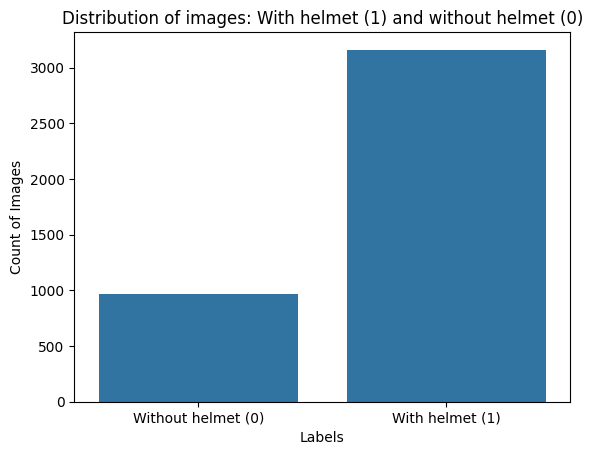

In [ ]:
# this code creates a countplot of the class distribution
sns.countplot(x=labels['label'])
plt.xlabel('Labels')
plt.ylabel('Count of Images')
plt.title('Distribution of images: With helmet (1) and without helmet (0)')
plt.xticks([0, 1], ['Without helmet (0)', 'With helmet (1)'])
plt.show()

***Observations:***

* There is significant imbalance in the classes.

* There are close to 1000 images without helmet and more than 3000 images with helmet.

### Random images from each of the classes have been plotted with their corresponding labels.

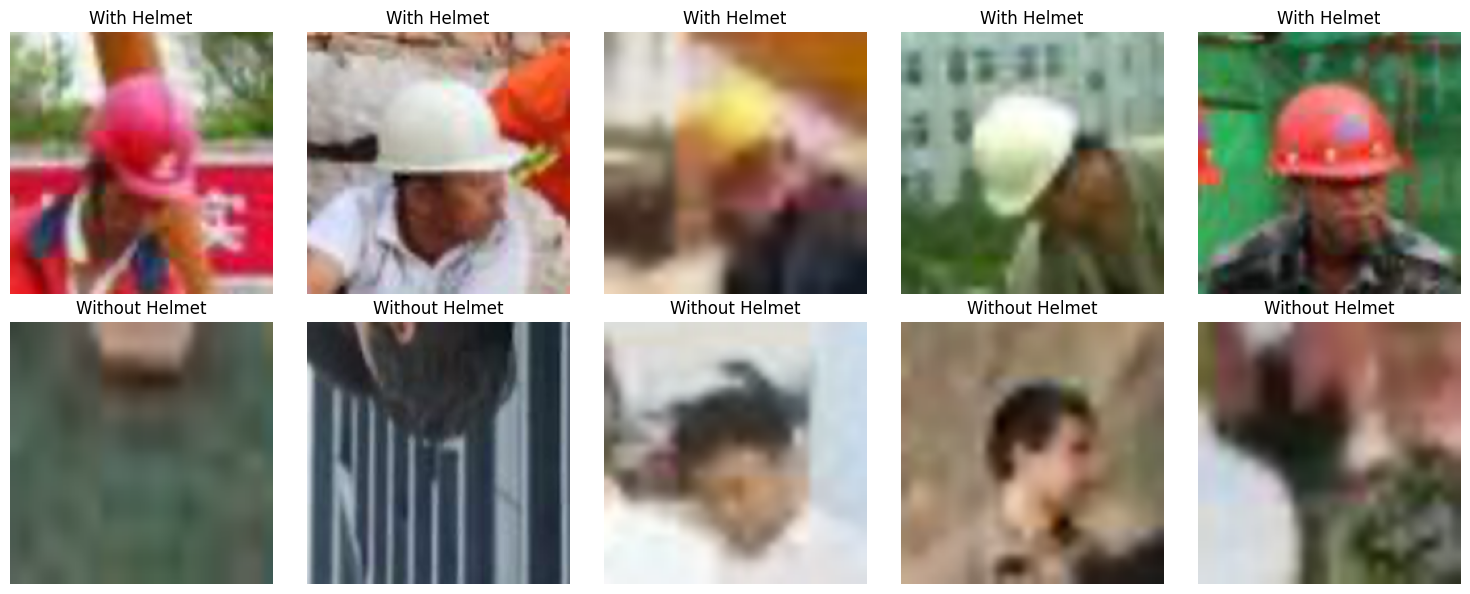

In [ ]:
# this code retrieves the indices of each of the classes
with_helmet_indices = np.where(labels_np == 1)[0]
without_helmet_indices = np.where(labels_np == 0)[0]

# this code selects 5 random indices to plot
num_samples = 5
random_idxs_with_helmet = np.random.choice(with_helmet_indices, num_samples, replace=False)
random_idxs_without_helmet = np.random.choice(without_helmet_indices, num_samples, replace=False)

fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))

# this code plots the images with helmet
for i, idx in enumerate(random_idxs_with_helmet):
    img = images[idx]
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    axes[0, i].set_title('With Helmet')
    axes[0, i].set_aspect('equal')

# this code plots the images without helmet
for i, idx in enumerate(random_idxs_without_helmet):
    img = images[idx]
    axes[1, i].imshow(img)
    axes[1, i].axis('off')
    axes[1, i].set_title('Without Helmet')
    axes[1, i].set_aspect('equal')

plt.tight_layout()
plt.show()


***Observations***

* Some of the images are blurred, inverted and difficult to see.

* This may have an impact on the model building.

# **Data Preprocessing**

### Splitting the dataset



In [ ]:
# this code splits the train-temp data 70/30
X_train, X_temp, y_train, y_temp = train_test_split(images, labels_np, test_size=0.3, random_state=42, stratify=labels_np)

# this code splits the temp data 50/50
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [ ]:
# this code prints the shape of the train, validation and test data
print(f"Train data: {X_train.shape[0]}")
print(f"Validation data: {X_val.shape[0]}")
print(f"Test data: {X_test.shape[0]}")

Train data: 2887
Validation data: 619
Test data: 619


### Data Normalization

In [ ]:
# this code standardizes the pixels of the images
X_train = (X_train / 255.0).astype(np.float32)
X_val = (X_val / 255.0).astype(np.float32)
X_test = (X_test / 255.0).astype(np.float32)

In [ ]:
# this code prints the minimum and maximum pixels of the train, validation and test data
print(f"Train min: {X_train.min()}, Train max: {X_train.max()}")
print(f"Validation min: {X_val.min()}, Validation max: {X_val.max()}")
print(f"Test min: {X_test.min()}, Test max: {X_test.max()}")

Train min: 0.0, Train max: 1.0
Validation min: 0.0, Validation max: 1.0
Test min: 0.0, Test max: 1.0


***Observation***
* The pixel values are between 0.0 and 1.0


# **Model Building**

##Model Evaluation Criterion

## Utility Functions

In [ ]:
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    # target is already a numpy array, no need to call .to_numpy()
    target = target.reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='micro')  # to compute Recall
    precision = precision_score(target, pred, average='micro')  # to compute Precision
    f1 = f1_score(target, pred, average='micro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [ ]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    # target is already a numpy array, no need to call .to_numpy()
    target = target.reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

##Model 1: Convolutional Neural Network (CNN) from Scratch

In [ ]:
# this code defines the Convolutional Neural Network
model_1 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')])

# this code compiles the model
model_1.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 99, 99, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 23, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,761,537 (33.42 MB)

 Trainable params: 8,761,089 (33.42 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# this code trains the model
history_1 = model_1.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    shuffle=True,
    verbose=2)

Epoch 1/10
91/91 - 8s - 93ms/step - accuracy: 0.9737 - loss: 0.0672 - val_accuracy: 0.9176 - val_loss: 1.0213
Epoch 2/10
91/91 - 6s - 69ms/step - accuracy: 0.9709 - loss: 0.0662 - val_accuracy: 0.9128 - val_loss: 1.5525
Epoch 3/10
91/91 - 6s - 66ms/step - accuracy: 0.9737 - loss: 0.0746 - val_accuracy: 0.8966 - val_loss: 1.3485
Epoch 4/10
91/91 - 6s - 68ms/step - accuracy: 0.9699 - loss: 0.0825 - val_accuracy: 0.9144 - val_loss: 1.0199
Epoch 5/10
91/91 - 6s - 66ms/step - accuracy: 0.9747 - loss: 0.0580 - val_accuracy: 0.9063 - val_loss: 0.8692
Epoch 6/10
91/91 - 7s - 73ms/step - accuracy: 0.9751 - loss: 0.0566 - val_accuracy: 0.9144 - val_loss: 0.7875
Epoch 7/10
91/91 - 6s - 66ms/step - accuracy: 0.9764 - loss: 0.0531 - val_accuracy: 0.9111 - val_loss: 0.8029
Epoch 8/10
91/91 - 6s - 69ms/step - accuracy: 0.9733 - loss: 0.0640 - val_accuracy: 0.9176 - val_loss: 0.9493
Epoch 9/10
91/91 - 6s - 67ms/step - accuracy: 0.9751 - loss: 0.0777 - val_accuracy: 0.9111 - val_loss: 0.7813
Epoch 10/1

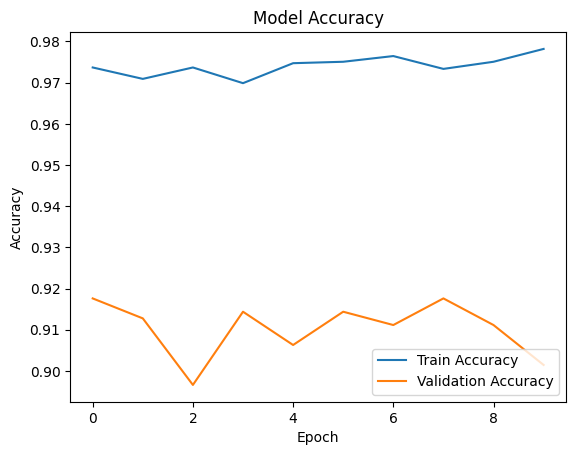

In [ ]:
# this code creates a plot of the accuracy of the train and validation data per epoch
plt.plot(history_1.history['accuracy'], label='Train Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

***Observations***

* The accuracy of the training set starts around 0.97 and appears to be slightly consistent, with little fluctuations.

* It appears that the model is learning the training data well.

* However, the accuracy of the validation set hovers around 0.90 with major fluctuations and instability.

* It appears that there is overfitting such that the model has learnt the training data all too well.

In [ ]:
# this code evaluates the training performance of the model
model_1_train_perf = model_performance_classification(model_1, X_train, y_train)
print("Train performance metrics:")
model_1_train_perf

91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
Train performance metrics:


,Accuracy,Recall,Precision,F1 Score
0,0.988916,0.988916,0.988916,0.988916


91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step


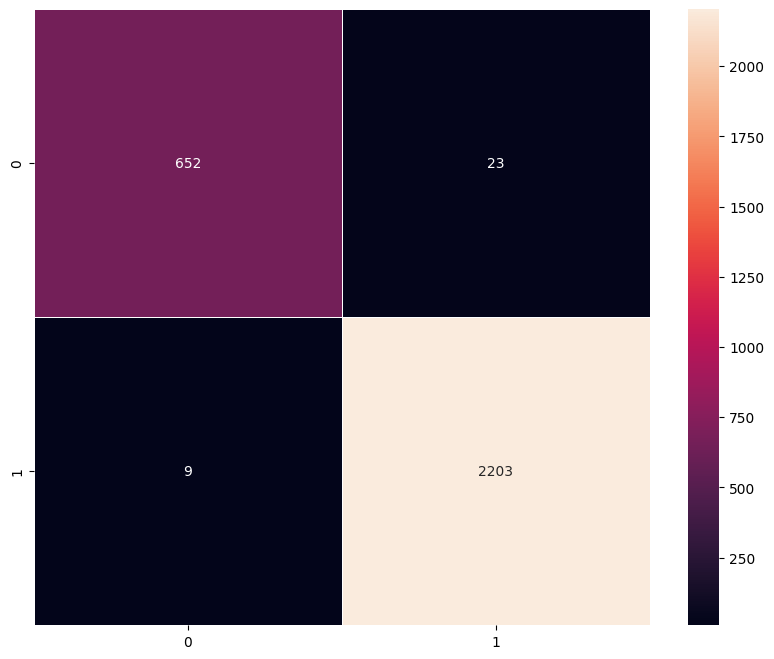

In [ ]:
# this code plots the confusion matrix of the tain set
plot_confusion_matrix(model_1, X_train, y_train)

In [ ]:
# this code evaluates the performance of the validation set
model_1_val_perf = model_performance_classification(model_1, X_val, y_val)
print("Validation performance metrics:")
model_1_val_perf

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Validation performance metrics:


,Accuracy,Recall,Precision,F1 Score
0,0.901454,0.901454,0.901454,0.901454


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


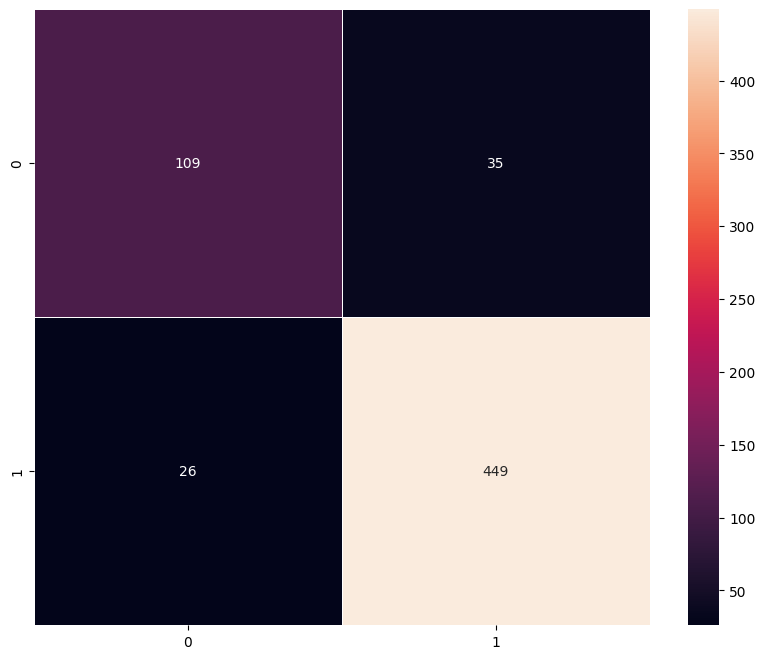

In [ ]:
# this code plots the confusion matrix of the validation set
plot_confusion_matrix(model_1, X_val, y_val)

### Visualizing the predictions

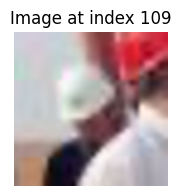

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
Predicted Label: 1
True Label: 1


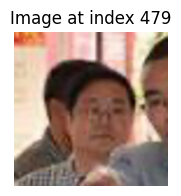

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Predicted Label: 0
True Label: 0


In [ ]:
# this code visualizes and predicts for index 109
index = 109
plt.figure(figsize=(2,2))
plt.imshow(X_val[index])
plt.title(f"Image at index {index}")
plt.axis('off')
plt.show()

prediction = model_1.predict(X_val[index].reshape(1, X_val.shape[1], X_val.shape[2], X_val.shape[3]))
predicted_label = 1 if prediction[0][0] > 0.5 else 0
print('Predicted Label:', predicted_label)
print('True Label:', y_val[index])

# this code visualizes and predicts for index 479
index = 479
plt.figure(figsize=(2,2))
plt.imshow(X_val[index])
plt.title(f"Image at index {index}")
plt.axis('off')
plt.show()

prediction = model_1.predict(X_val[index].reshape(1, X_val.shape[1], X_val.shape[2], X_val.shape[3]))
predicted_label = 1 if prediction[0][0] > 0.5 else 0
print('Predicted Label:', predicted_label)
print('True Label:', y_val[index])

***Observations***

* Two images were randomly selected at index 109 and 479 to test.

* Based on the output, the model accurately predicted both images.

## Model 2: Transfer Learning with VGG-16 (Base)

In [ ]:
# this code loads the VGG16 model
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(200, 200, 3))

# this code freezes the layers of the VGG16 base model
for layer in vgg_base.layers:
    layer.trainable = False

# this code createa a new sequential model, adds the VGG16 base and new classification layers
model_2 = Sequential()
model_2.add(vgg_base)
model_2.add(Flatten())
model_2.add(Dense(128, activation='relu'))
model_2.add(Dropout(0.5))
model_2.add(Dense(1, activation='sigmoid'))

# this code compiles the model
model_2.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

model_2.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,074,241 (65.13 MB)

 Trainable params: 2,359,553 (9.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# this code trains model_2
history_2 = model_2.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    shuffle=True,
    verbose=2)

Epoch 1/10
91/91 - 19s - 207ms/step - accuracy: 0.7710 - loss: 0.5405 - val_accuracy: 0.8174 - val_loss: 0.3431
Epoch 2/10
91/91 - 13s - 143ms/step - accuracy: 0.8386 - loss: 0.3330 - val_accuracy: 0.8514 - val_loss: 0.3055
Epoch 3/10
91/91 - 13s - 148ms/step - accuracy: 0.8601 - loss: 0.2957 - val_accuracy: 0.8643 - val_loss: 0.2796
Epoch 4/10
91/91 - 13s - 148ms/step - accuracy: 0.8853 - loss: 0.2626 - val_accuracy: 0.8675 - val_loss: 0.2761
Epoch 5/10
91/91 - 20s - 220ms/step - accuracy: 0.8957 - loss: 0.2491 - val_accuracy: 0.8756 - val_loss: 0.2616
Epoch 6/10
91/91 - 21s - 229ms/step - accuracy: 0.9044 - loss: 0.2222 - val_accuracy: 0.8853 - val_loss: 0.2491
Epoch 7/10
91/91 - 13s - 146ms/step - accuracy: 0.9131 - loss: 0.2150 - val_accuracy: 0.8869 - val_loss: 0.2438
Epoch 8/10
91/91 - 14s - 149ms/step - accuracy: 0.9089 - loss: 0.2185 - val_accuracy: 0.8869 - val_loss: 0.2510
Epoch 9/10
91/91 - 13s - 148ms/step - accuracy: 0.9238 - loss: 0.1992 - val_accuracy: 0.8869 - val_loss:

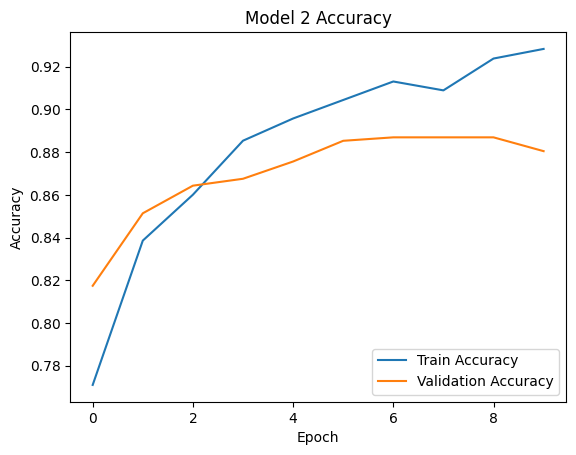

In [ ]:
# this code creates a plot of the accuracy of the train and validation data per epoch
plt.plot(history_2.history['accuracy'], label='Train Accuracy')
plt.plot(history_2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

***Observations***

* The accuracy of the training set begins at a low value (around 0.77) compared to Model 1.

* Model 2 however shows a strong and consistent upward trend throughout the 10 epochs. The accuracy reaches about 0.92.

* This indicates that the VGG16 base model is learning efficiently from the training data.

* The accuracy of the validation set also shows an initial improvement compared to Model 1. It begins around 0.81 and increases steadily before a slight drop.

* Compared to Model 1, the disconnect between the accuracy of the training and validation set is less severe with Model 2.

* The accuracy of the taining set is more steady.

* It is likely that there is still overfitting in Model 2
because the accuracy of the training set is still higher than that of the validation set and it continues to rise. In addition, the validation loss increases as the training loss decreases.

In [ ]:
# this code evaluates the training performance
model_2_train_perf = model_performance_classification(model_2, X_train, y_train)
print("Train performance metric for Model 2:")
model_2_train_perf

91/91 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step
Train performance metric for Model 2:


,Accuracy,Recall,Precision,F1 Score
0,0.964669,0.964669,0.964669,0.964669


91/91 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step


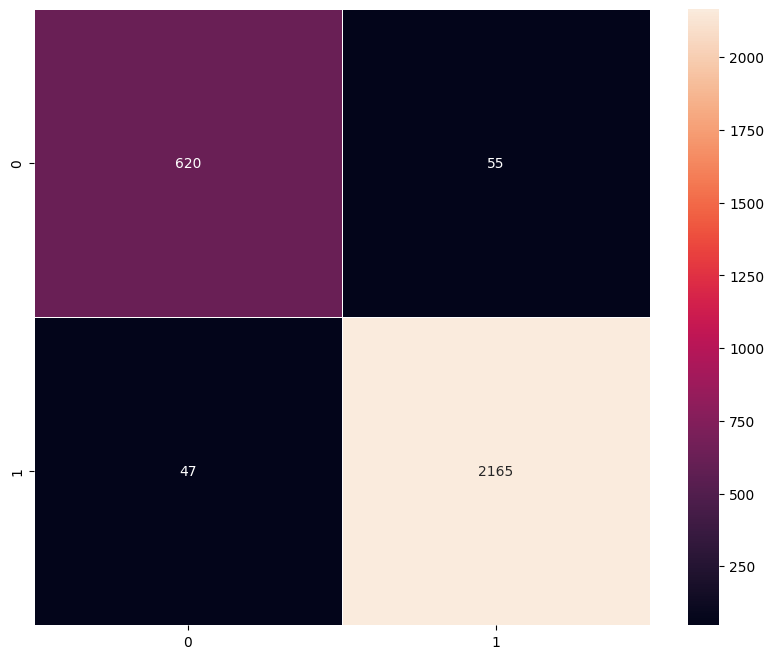

In [ ]:
# this code plots the confusion matrix for the training set
plot_confusion_matrix(model_2, X_train, y_train)

In [ ]:
# this code evaluates the validation performance
model_2_val_perf = model_performance_classification(model_2, X_val, y_val)
print("Validation performance metric for Model 2:")
model_2_val_perf

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step
Validation performance metric for Model 2:


,Accuracy,Recall,Precision,F1 Score
0,0.880452,0.880452,0.880452,0.880452


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step


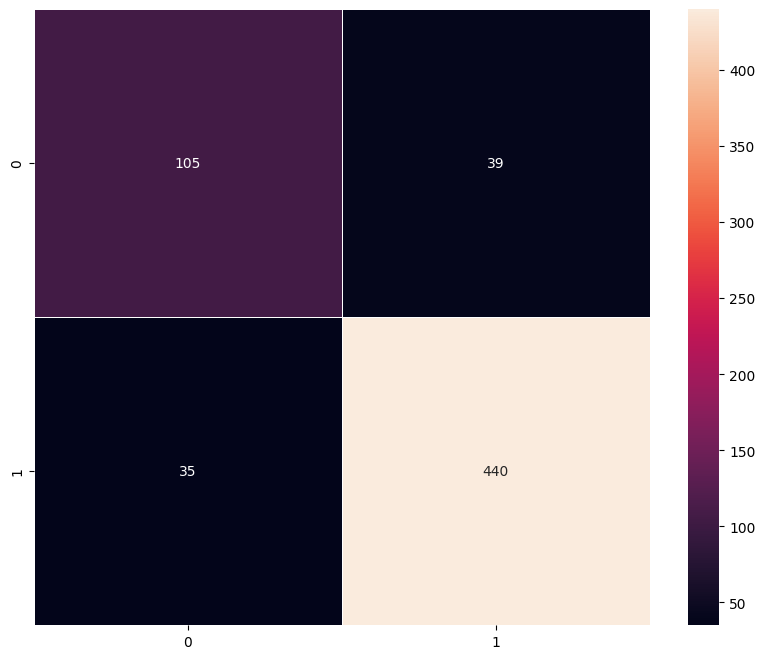

In [ ]:
# this code plots the confusion matrix for the validation set
plot_confusion_matrix(model_2, X_val, y_val)

### Visualizing the predictions

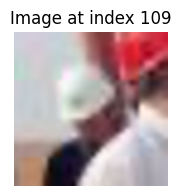

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Predicted Label: 1
True Label: 1


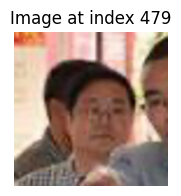

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted Label: 0
True Label: 0


In [ ]:
# this code visualizes and predicts for index 109
index = 109
plt.figure(figsize=(2,2))
plt.imshow(X_val[index])
plt.title(f"Image at index {index}")
plt.axis('off')
plt.show()

prediction = model_2.predict(X_val[index].reshape(1, X_val.shape[1], X_val.shape[2], X_val.shape[3]))
predicted_label = 1 if prediction[0][0] > 0.5 else 0
print('Predicted Label:', predicted_label)
print('True Label:', y_val[index])

# this code visualizes and predicts for index 479
index = 479
plt.figure(figsize=(2,2))
plt.imshow(X_val[index])
plt.title(f"Image at index {index}")
plt.axis('off')
plt.show()

prediction = model_2.predict(X_val[index].reshape(1, X_val.shape[1], X_val.shape[2], X_val.shape[3]))
predicted_label = 1 if prediction[0][0] > 0.5 else 0
print('Predicted Label:', predicted_label)
print('True Label:', y_val[index])

***Observations***

* Maintaining the same images at indices 109 and 479, model_2 was able to accurately make the prediction.

## Model 3: Transfer Learning with VGG-16 (Base + FFNN)





In [ ]:
# this code loads the VGG16 model
vgg_base_ffnn = VGG16(weights='imagenet', include_top=False, input_shape=(200, 200, 3))

# this code freezes the layers of the VGG16 base model
for layer in vgg_base.layers:
    layer.trainable = False

# this code create a new model (Model 3) on top of the VGG16 base and adds a Feed Forward Neural Network
model_3 = Sequential()
model_3.add(vgg_base_ffnn)
model_3.add(Flatten())
model_3.add(Dense(128, activation='relu'))
model_3.add(Dropout(0.5))
model_3.add(Dense(1, activation='sigmoid'))

# this code compiles the model
model_3.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,074,241 (65.13 MB)

 Trainable params: 17,074,241 (65.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# this code trains model_3
history_3 = model_3.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    shuffle=True,
    verbose=2)

Epoch 1/10
91/91 - 44s - 478ms/step - accuracy: 0.7513 - loss: 0.7060 - val_accuracy: 0.8174 - val_loss: 0.3736
Epoch 2/10
91/91 - 34s - 372ms/step - accuracy: 0.8292 - loss: 0.3622 - val_accuracy: 0.8595 - val_loss: 0.2996
Epoch 3/10
91/91 - 34s - 374ms/step - accuracy: 0.8715 - loss: 0.2993 - val_accuracy: 0.9031 - val_loss: 0.2534
Epoch 4/10
91/91 - 35s - 382ms/step - accuracy: 0.8756 - loss: 0.2902 - val_accuracy: 0.8465 - val_loss: 0.4535
Epoch 5/10
91/91 - 34s - 376ms/step - accuracy: 0.8736 - loss: 0.2915 - val_accuracy: 0.9063 - val_loss: 0.2282
Epoch 6/10
91/91 - 35s - 380ms/step - accuracy: 0.9117 - loss: 0.2414 - val_accuracy: 0.9047 - val_loss: 0.2821
Epoch 7/10
91/91 - 34s - 370ms/step - accuracy: 0.9196 - loss: 0.2107 - val_accuracy: 0.9208 - val_loss: 0.2127
Epoch 8/10
91/91 - 33s - 365ms/step - accuracy: 0.9176 - loss: 0.2075 - val_accuracy: 0.9176 - val_loss: 0.1984
Epoch 9/10
91/91 - 33s - 365ms/step - accuracy: 0.9110 - loss: 0.2054 - val_accuracy: 0.9225 - val_loss:

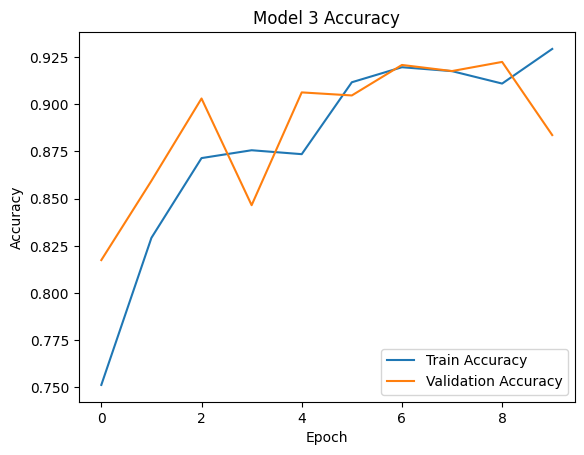

In [ ]:
# this code creates a plot of the accuracy of the train and validation data per epoch
plt.plot(history_3.history['accuracy'], label='Train Accuracy')
plt.plot(history_3.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 3 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

***Observations***

* The accuracy of the training set for Model 3 begin around 0.75 and shows a good increasing trend throughout the 10 epochs.

* Although there are some fluctuations, the overall learning progress is clear.

* The accuracy of the validation set also shows an improving trend. It begins around 0.81, peaks around 0.92 and drops to about 0.87.

* The fluctuation of the validation set are sharper.

* Compared to Models 1 and 2, there is a better balance between the accuracy of the training set and the validation set.

* Considering the drop in the accuracy of the validation set towards the end while the accuracy of the training set continues to increase shows that there are still signs of overfitting.

* In addition, the validation loss increases slightly while the trainig loss decreases significantly.

* It appears that Model 3 possess more robust abilities compared to Models 1 and 2. However, overfitting is evident and hence, training can be stopped before 10 epochs.

In [ ]:
# this code evaluates the training performance on model 3
model_3_train_perf = model_performance_classification(model_3, X_train, y_train)
print("Train performance metric for Model 3:")
model_3_train_perf

91/91 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step
Train performance metric for Model 3:


,Accuracy,Recall,Precision,F1 Score
0,0.904399,0.904399,0.904399,0.904399


91/91 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step


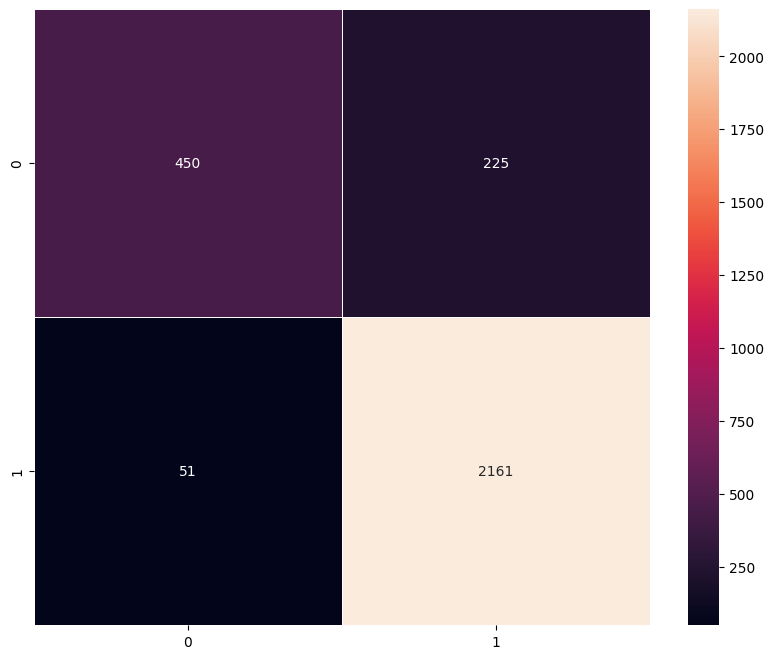

In [ ]:
# this code creates the confusion matrix of training set
plot_confusion_matrix(model_3, X_train, y_train)

In [ ]:
# this code evaluates the validation performance on model 3
model_3_val_perf = model_performance_classification(model_3, X_val, y_val)
print("Validation performance metric for Model 3:")
model_3_val_perf

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step
Validation performance metric for Model 3:


,Accuracy,Recall,Precision,F1 Score
0,0.883683,0.883683,0.883683,0.883683


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step


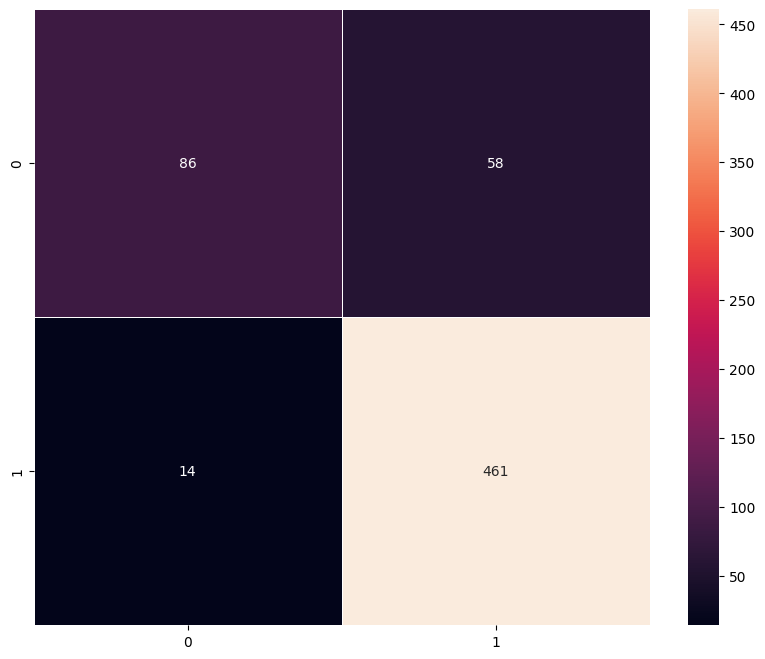

In [ ]:
# this code creates the confusion matrix of the validation set
plot_confusion_matrix(model_3, X_val, y_val)

#### Visualizing the predictions

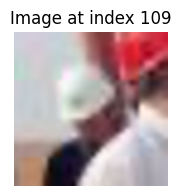

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Predicted Label: 1
True Label: 1


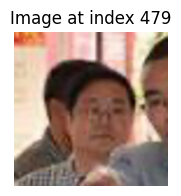

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Predicted Label: 0
True Label: 0


In [ ]:
# this code visualizes and predicts for index 109
index = 109
plt.figure(figsize=(2,2))
plt.imshow(X_val[index])
plt.title(f"Image at index {index}")
plt.axis('off')
plt.show()

prediction = model_3.predict(X_val[index].reshape(1, X_val.shape[1], X_val.shape[2], X_val.shape[3]))
predicted_label = 1 if prediction[0][0] > 0.5 else 0
print('Predicted Label:', predicted_label)
print('True Label:', y_val[index])

# this code visualizes and predicts for index 479
index = 479
plt.figure(figsize=(2,2))
plt.imshow(X_val[index])
plt.title(f"Image at index {index}")
plt.axis('off')
plt.show()

prediction = model_3.predict(X_val[index].reshape(1, X_val.shape[1], X_val.shape[2], X_val.shape[3]))
predicted_label = 1 if prediction[0][0] > 0.5 else 0
print('Predicted Label:', predicted_label)
print('True Label:', y_val[index])

***Observations***

* Maintaining the same images, Model 3 was able to make accurate predictions.

## Model 4: Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Data augmentation was used in the train data set only.

In [ ]:
# this code initializes the ImageDataGenerator for data augmentation on the training set
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

# this code loads the VGG16 model again for Model 4
vgg_base_aug = VGG16(weights='imagenet', include_top=False, input_shape=(200, 200, 3))

# this code freezes the layers of the VGG16 base model for Model 4
for layer in vgg_base_aug.layers:
    layer.trainable = False

# This code creates Model 4 on top of the VGG16 base with a Feed Forward Neural Network head
model_4 = Sequential()
model_4.add(vgg_base_aug)
model_4.add(Flatten())
model_4.add(Dense(128, activation='relu'))
model_4.add(Dropout(0.5))
model_4.add(Dense(1, activation='sigmoid'))

# This code compiles Model 4
model_4.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,074,241 (65.13 MB)

 Trainable params: 2,359,553 (9.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# this code trains model_4
history_4 = model_4.fit(
    train_datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_val, y_val),
    shuffle=True,
    verbose=2)

Epoch 1/10
91/91 - 67s - 735ms/step - accuracy: 0.7534 - loss: 0.5929 - val_accuracy: 0.7932 - val_loss: 0.3809
Epoch 2/10
91/91 - 53s - 586ms/step - accuracy: 0.7835 - loss: 0.4372 - val_accuracy: 0.8352 - val_loss: 0.3494
Epoch 3/10
91/91 - 56s - 615ms/step - accuracy: 0.8053 - loss: 0.4077 - val_accuracy: 0.8481 - val_loss: 0.3496
Epoch 4/10
91/91 - 41s - 454ms/step - accuracy: 0.8098 - loss: 0.4006 - val_accuracy: 0.8449 - val_loss: 0.3179
Epoch 5/10
91/91 - 46s - 500ms/step - accuracy: 0.8213 - loss: 0.3880 - val_accuracy: 0.8384 - val_loss: 0.3185
Epoch 6/10
91/91 - 39s - 432ms/step - accuracy: 0.8254 - loss: 0.3680 - val_accuracy: 0.8740 - val_loss: 0.3309
Epoch 7/10
91/91 - 37s - 411ms/step - accuracy: 0.8192 - loss: 0.3653 - val_accuracy: 0.8611 - val_loss: 0.2981
Epoch 8/10
91/91 - 39s - 432ms/step - accuracy: 0.8278 - loss: 0.3709 - val_accuracy: 0.8514 - val_loss: 0.2973
Epoch 9/10
91/91 - 40s - 436ms/step - accuracy: 0.8282 - loss: 0.3644 - val_accuracy: 0.8675 - val_loss:

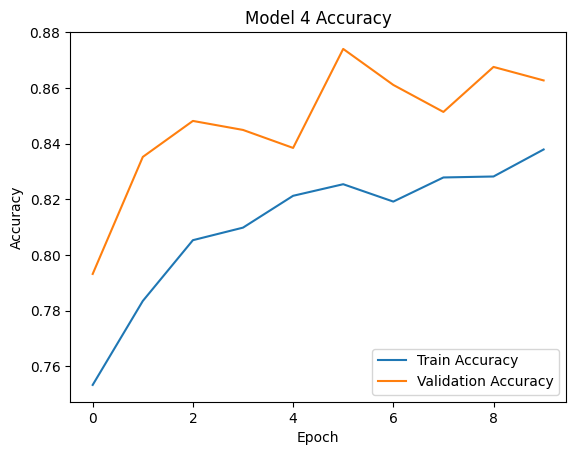

In [ ]:
# this code creates a plot of the accuracy of the train and validation data per epoch
plt.plot(history_4.history['accuracy'], label='Train Accuracy')
plt.plot(history_4.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 4 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

***Observations***

* The accuracy of the training  set for Model 4 begins around 0.75 and shows a gradual upward trend.

* It fluctuates slightly and ends around 0.83. The accuracy of the training set for Model 4 is generally lower compared to that of Models 1, 2 and 3.

* The accuracy of the validation set begins around 0.79 and also shows an increasing trend.

* There are sharper and significant fluctuations.

* Model 4 has a smaller gap between the training and validation set compared to Model 1. Data augmentation appears to decrease the severity of overfitting although the accuracy is still lower.

* Likewise, the accuracy of the validation set is lower compared to that of Model 3.

In [ ]:
# this code evaluates the performance of the training set
model_4_train_perf = model_performance_classification(model_4, X_train, y_train)
print("Train performance metric for Model 4:")
model_4_train_perf

91/91 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step
Train performance metric for Model 4:


,Accuracy,Recall,Precision,F1 Score
0,0.897125,0.897125,0.897125,0.897125


91/91 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step


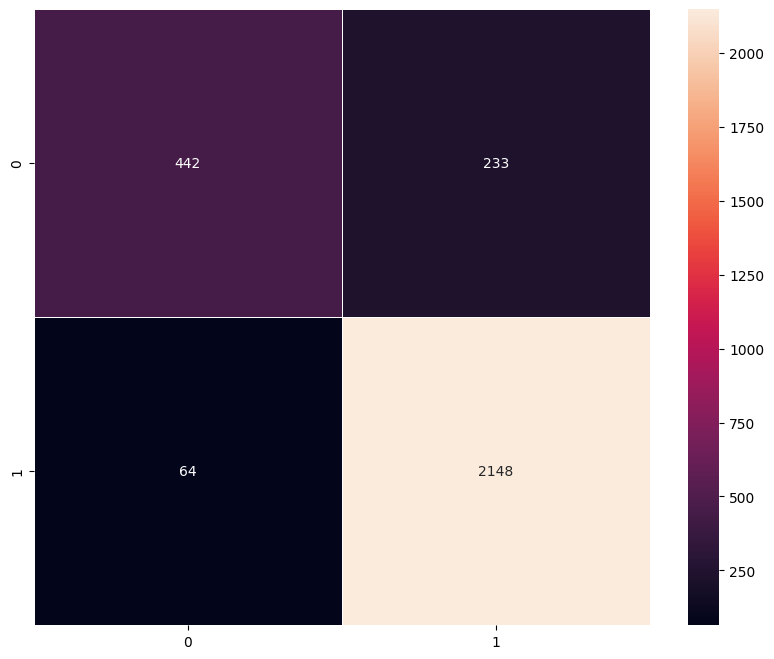

In [ ]:
# this code creates the confusion matrix of the training set
plot_confusion_matrix(model_4, X_train, y_train)

In [ ]:
# this code evaluates the performance of the validation set
model_4_val_perf = model_performance_classification(model_4, X_val, y_val)
print("Validation performance metric for Model 4:")
model_4_val_perf

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step
Validation performance metric for Model 4:


,Accuracy,Recall,Precision,F1 Score
0,0.862682,0.862682,0.862682,0.862682


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step


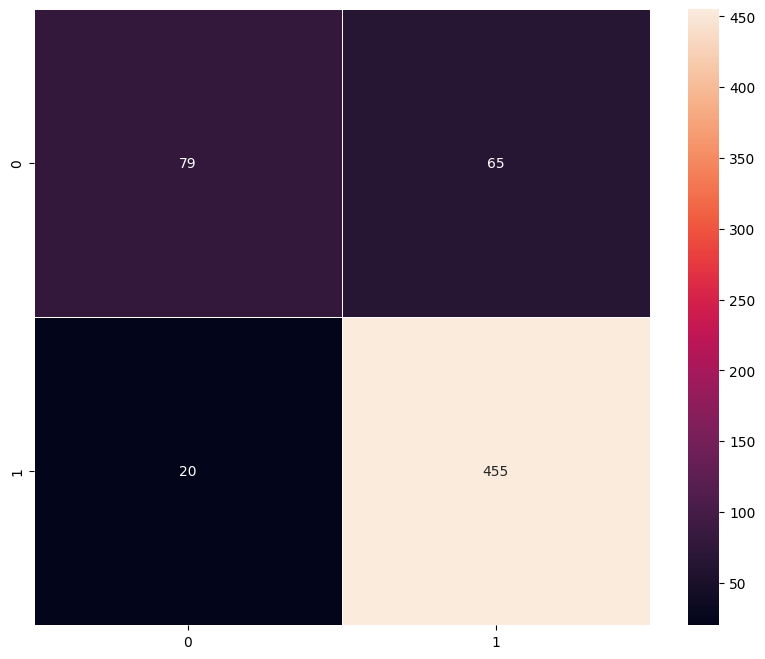

In [ ]:
# this code creates the confusion matrix of the validation set
plot_confusion_matrix(model_4, X_val, y_val)

#### Visualizing the predictions

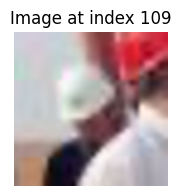

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Predicted Label: 1
True Label: 1


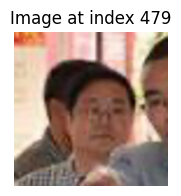

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Predicted Label: 0
True Label: 0


In [ ]:
# this code visualizes and predicts for index 109
index = 109
plt.figure(figsize=(2,2))
plt.imshow(X_val[index])
plt.title(f"Image at index {index}")
plt.axis('off')
plt.show()

prediction = model_4.predict(X_val[index].reshape(1, X_val.shape[1], X_val.shape[2], X_val.shape[3]))
predicted_label = 1 if prediction[0][0] > 0.5 else 0
print('Predicted Label:', predicted_label)
print('True Label:', y_val[index])

# this code visualizes and predicts for index 479
index = 479
plt.figure(figsize=(2,2))
plt.imshow(X_val[index])
plt.title(f"Image at index {index}")
plt.axis('off')
plt.show()

prediction = model_4.predict(X_val[index].reshape(1, X_val.shape[1], X_val.shape[2], X_val.shape[3]))
predicted_label = 1 if prediction[0][0] > 0.5 else 0
print('Predicted Label:', predicted_label)
print('True Label:', y_val[index])

***Observations***

* Maintaining the same two image indices, Model 4 appears to have accurately made the predictions.

# **Model Performance Comparison and Final Model Selection**

In [ ]:
# this code puts all the performance metrics into a single DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Model 1 (CNN from Scratch)', 'Model 2 (VGG16 Base)', 'Model 3 (VGG16 + FFNN)', 'Model 4 (VGG16 + FFNN + Augmentation)']
})

# this code appends the training metrics
comparison_df['Train_Accuracy'] = [model_1_train_perf['Accuracy'][0], model_2_train_perf['Accuracy'][0], model_3_train_perf['Accuracy'][0], model_4_train_perf['Accuracy'][0]]
comparison_df['Train_Recall'] = [model_1_train_perf['Recall'][0], model_2_train_perf['Recall'][0], model_3_train_perf['Recall'][0], model_4_train_perf['Recall'][0]]
comparison_df['Train_Precision'] = [model_1_train_perf['Precision'][0], model_2_train_perf['Precision'][0], model_3_train_perf['Precision'][0], model_4_train_perf['Precision'][0]]
comparison_df['Train_F1_Score'] = [model_1_train_perf['F1 Score'][0], model_2_train_perf['F1 Score'][0], model_3_train_perf['F1 Score'][0], model_4_train_perf['F1 Score'][0]]

# this code appends the validation metrics
comparison_df['Val_Accuracy'] = [model_1_val_perf['Accuracy'][0], model_2_val_perf['Accuracy'][0], model_3_val_perf['Accuracy'][0], model_4_val_perf['Accuracy'][0]]
comparison_df['Val_Recall'] = [model_1_val_perf['Recall'][0], model_2_val_perf['Recall'][0], model_3_val_perf['Recall'][0], model_4_val_perf['Recall'][0]]
comparison_df['Val_Precision'] = [model_1_val_perf['Precision'][0], model_2_val_perf['Precision'][0], model_3_val_perf['Precision'][0], model_4_val_perf['Precision'][0]]
comparison_df['Val_F1_Score'] = [model_1_val_perf['F1 Score'][0], model_2_val_perf['F1 Score'][0], model_3_val_perf['F1 Score'][0], model_4_val_perf['F1 Score'][0]]

In [ ]:
print("\n--- Model Performance Comparison ---")
comparison_df.round(4)


--- Model Performance Comparison ---


,Model,Train_Accuracy,Train_Recall,Train_Precision,Train_F1_Score,Val_Accuracy,Val_Recall,Val_Precision,Val_F1_Score
0,Model 1 (CNN from Scratch),0.9889,0.9889,0.9889,0.9889,0.9015,0.9015,0.9015,0.9015
1,Model 2 (VGG16 Base),0.9647,0.9647,0.9647,0.9647,0.8805,0.8805,0.8805,0.8805
2,Model 3 (VGG16 + FFNN),0.9044,0.9044,0.9044,0.9044,0.8837,0.8837,0.8837,0.8837
3,Model 4 (VGG16 + FFNN + Augmentation),0.8971,0.8971,0.8971,0.8971,0.8627,0.8627,0.8627,0.8627


***Observations***

* Model 1 has a high training accuracy but significantly low validation accuracy.

* Model 2 has a relatively smaller gap between the training and validation set and is an improvement on generalization compared to Model 1.

* Model 3 appears to show a good balance between the training accuracy and the validation accuracy. There is less overfitting and better generalization.

* Model 4 shows the lowest training accuracy even with data augmentation.

**Conclusion**
* Model 3 - VGG16 + FFNN seems to be the best and final model.

## Test Performance

In [ ]:
# this code evaluates the performance of the test set
model_3_test_perf = model_performance_classification(model_3, X_test, y_test)
print("Test performance metric for Model 3:")
model_3_test_perf

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step
Test performance metric for Model 3:


,Accuracy,Recall,Precision,F1 Score
0,0.872375,0.872375,0.872375,0.872375


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step


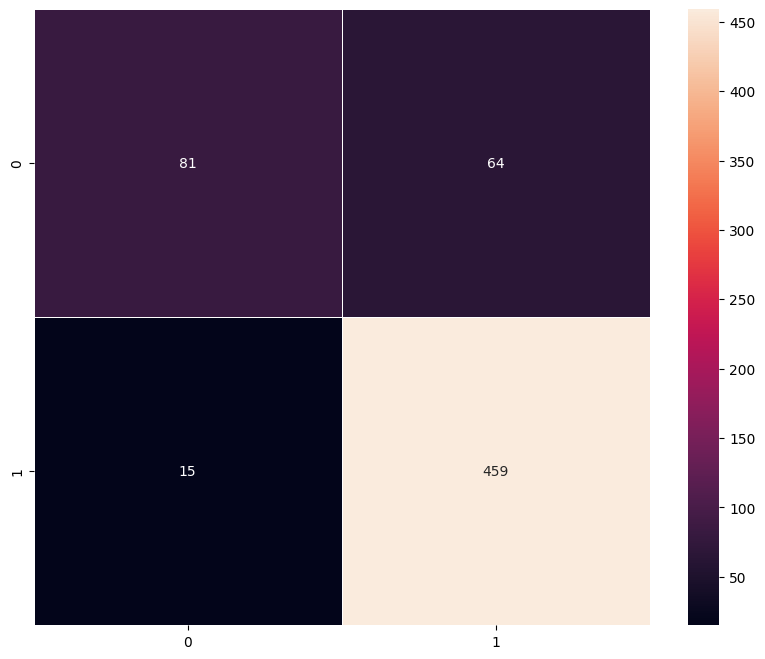

In [ ]:
# this code plots the confusion matrix for the test set
plot_confusion_matrix(model_3, X_test, y_test)

***Observations***

* Model 3 was used to assess the performance of the test set.

* The performance metrics hovers around 0.87 showing a fairly good abilities.

* The difference between the accuracy of the test and validation is not significant although the test accuracy is lower.

# **Actionable Insights & Recommendations**

- Four models were developed and they all performed fairly good however model 3 outperformed all the others.

- While the models were able to accurately predict the images, it is recommended that further testing is done to ensure that the model is 100% ready for deployment.

- It is recommended that Models 3 and 4 are further tested. This is because, even with data augmentation, model 4 could not outperform the other models however data augmentation is generally believed to improve the model significantly and address issues of overfitting. Futher testing will highlight how to use data augmentation appropriately to improve a model.

- It was observed that some of the images were blurred, inverted and almost unrecognizable. It is believed that these make the dataset more diverse and improves the models ability. All these factors must be taken into consideration in order to develop a model that will perform the function 100%.



<font size=5 color='blue'>Power Ahead!</font>
___